### Imports

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import yaml
from pathlib import Path
import torch
from ultralytics import YOLO, settings


### Paths

In [4]:
DATASET_PATH = Path("../data/baseline.yaml")
OUTPUT_PATH = Path("../models/")
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

### Configure runs directory

In [6]:
new_runs_dir = OUTPUT_PATH  
settings.update({'runs_dir': str(new_runs_dir)})

### Device selection


In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


### Load dataset configuration

In [10]:
with open(DATASET_PATH, 'r') as f:
    data_config = yaml.safe_load(f)
print(f"Number of classes: {data_config['nc']}")

Number of classes: 55


### Initialize model

In [12]:
model = YOLO("yolo11m.pt")

### Train the model


In [14]:
results = model.train(
    data=str(DATASET_PATH),      # Path to dataset YAML
    epochs=100,                   # Number of training epochs
    batch=-1,                     # Auto-batch size (optimizes GPU memory)
    imgsz=640,                    # Input image size
    device=device,                # GPU or CPU
    lr0=0.01,                     # Initial learning rate
    weight_decay=0.0005,          # L2 regularization
    momentum=0.937,               # SGD momentum
    augment=True,                 # Enable data augmentation
    workers=8,                    # Number of data loading workers
    patience=50,                  # Early stopping patience
    save=True,                    # Save checkpoints
    name="baseline_55class",      # Experiment name
    exist_ok=True,                # Overwrite existing folder
    verbose=True,                 # Print training logs
    seed=42,                       # Print training logs
    close_mosaic=50,
    copy_paste=0.5
    
)

print("Training completed!")

Ultralytics 8.4.41  Python-3.12.12 torch-2.2.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=50, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.5, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=..\data\baseline.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_55class, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_ma

2026/04/24 12:20:33 INFO mlflow.tracking.fluent: Experiment with name '/Shared/Ultralytics' does not exist. Creating a new experiment.


MLflow: logging run_id(f3d30db307b64c808609edf03602ff75) to ..\models\mlflow
MLflow: view at http://127.0.0.1:5000 with 'mlflow server --backend-store-uri ..\models\mlflow'
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to C:\Users\isazo\OneDrive\ \courses\partfolio\pet_projects\traffic-sign-detection\models\detect\baseline_55class
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/100       1.6G     0.7942      4.177      1.001          3        640: 100% ━━━━━━━━━━━━ 978/978 8.8it/s 1:51<0.1sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 221/221 14.7it/s 15.0s<0.1s
                   all        882       1393      0.574      0.314      0.275      0.231

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/100       1.6G     0.7766      2.448 

### Evaluate on validation set

In [16]:
best_model_path = OUTPUT_PATH / "detect/baseline_55class/weights/best.pt"
best_model = YOLO(str(best_model_path))

val_results = best_model.val(
    data=str(DATASET_PATH),      # Dataset configuration
    batch=16,                     # Validation batch size
    imgsz=640,                    # Image size for validation
    device=device,                # GPU or CPU
    verbose=True,                 # Print validation results
    name='baseline_55class_val'
)



Ultralytics 8.4.41  Python-3.12.12 torch-2.2.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO11m summary (fused): 126 layers, 20,072,437 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 526.3152.8 MB/s, size: 53.1 KB)
val: Scanning C:\Users\isazo\OneDrive\Рабочий стол\courses\partfolio\pet_projects\traffic-sign-detection\data\raw\Traffic Signs\valid\labels.cache... 882 images, 43 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 882/882  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 56/56 2.3it/s 23.9s0.4ss
                   all        882       1393      0.882      0.874      0.905      0.796
            forb_ahead         45         46      0.933      0.908      0.978      0.881
             forb_left         12         12      0.809      0.917      0.774      0.686
         forb_overtake         13         14      0.959          1      0.995       0.88
            forb_ri

### Print validation metrics

In [18]:
print("\nValidation Results:")
print(f"mAP50-95: {val_results.box.map:.4f}")
print(f"mAP50: {val_results.box.map50:.4f}")
print(f"Precision: {val_results.box.mp:.4f}")
print(f"Recall: {val_results.box.mr:.4f}")

print(f"\nModel saved to: {OUTPUT_PATH}")


Validation Results:
mAP50-95: 0.7958
mAP50: 0.9045
Precision: 0.8823
Recall: 0.8741

Model saved to: ..\models


### Visualization

In [53]:
import sys
sys.path.append('../scripts')  
from visualization import *
%matplotlib inline

In [55]:
df = load_results("baseline_55class")

Loaded 100 epochs from baseline_55class


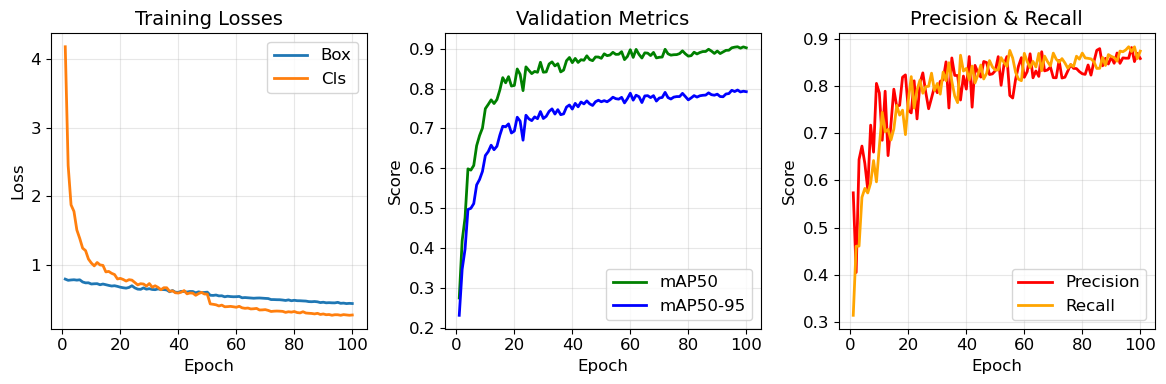

In [57]:
plot_losses(df)


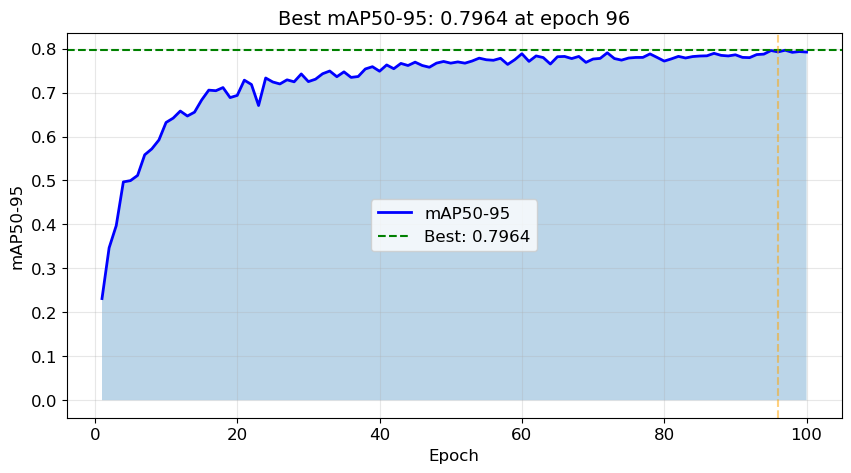

(96, 0.79644)

In [59]:
plot_map_progress(df)


In [61]:
print_summary(df)



TRAINING SUMMARY
Best mAP50-95:  0.7964 (epoch 96)
Final mAP50-95: 0.7923
Best mAP50:     0.9050
Best Precision: 0.8824
Best Recall:    0.8841

 Good! Only 4 epochs after peak


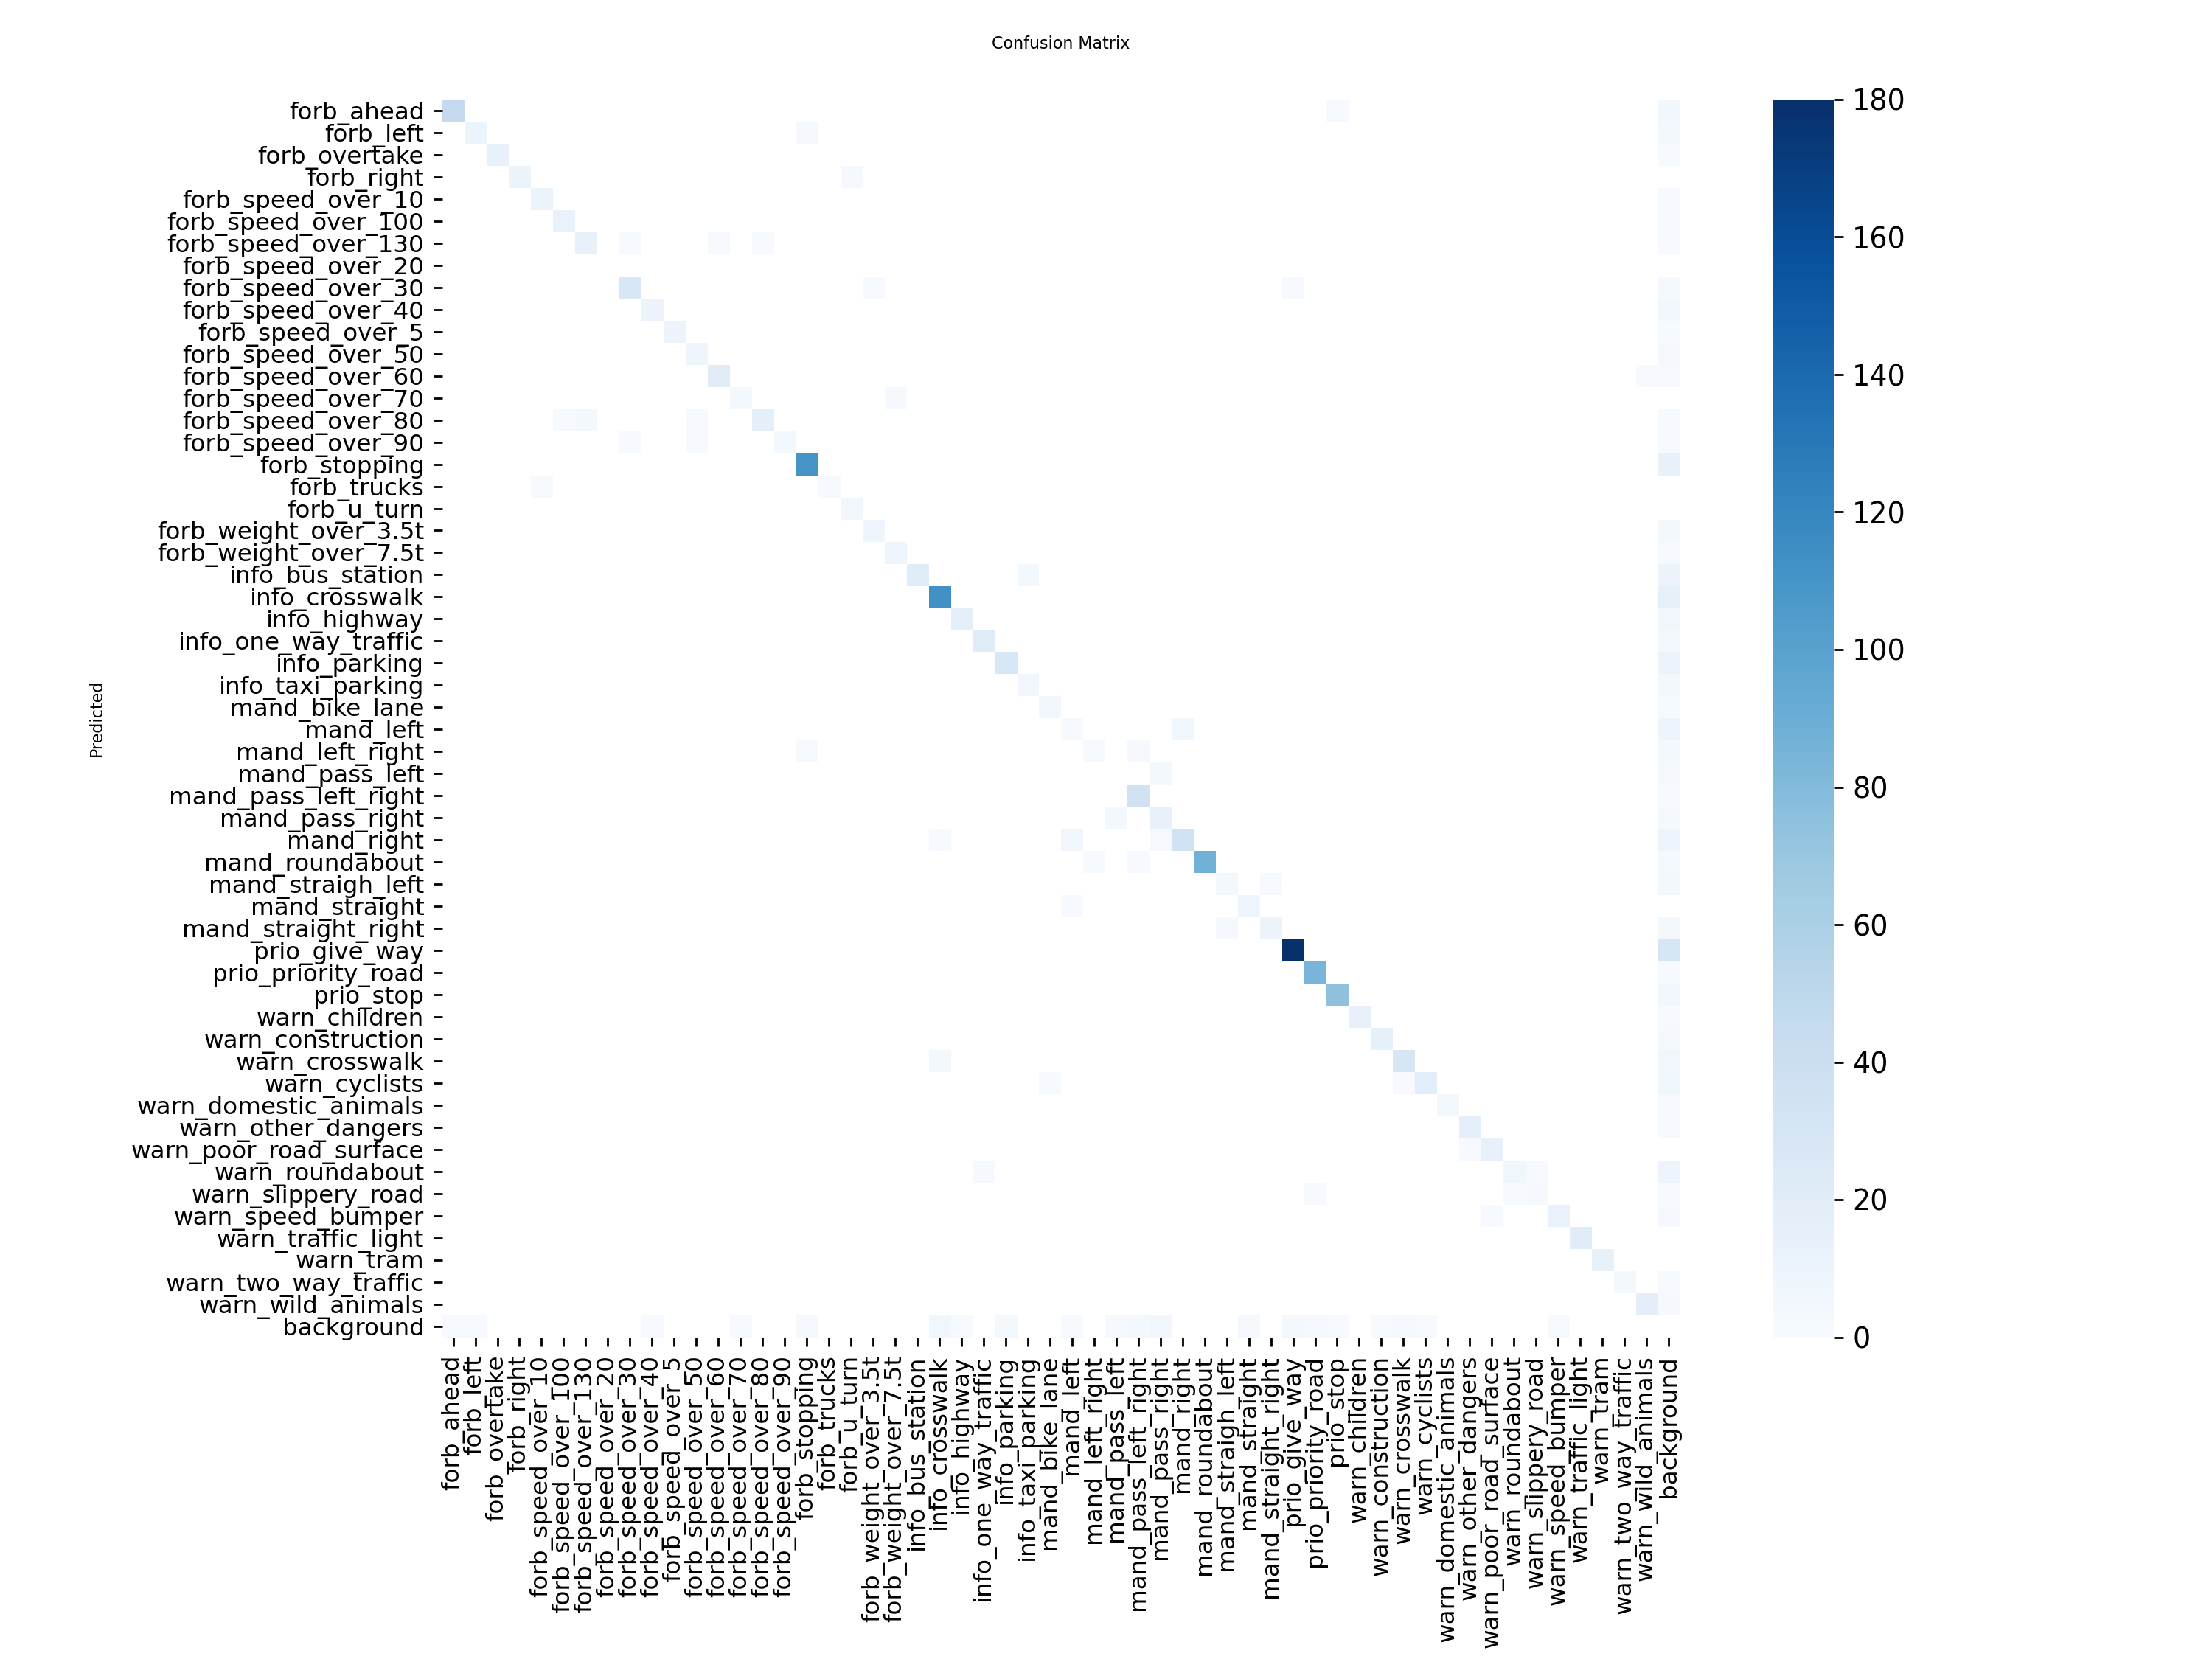

In [67]:
plot_confusion_matrix("baseline_55class")

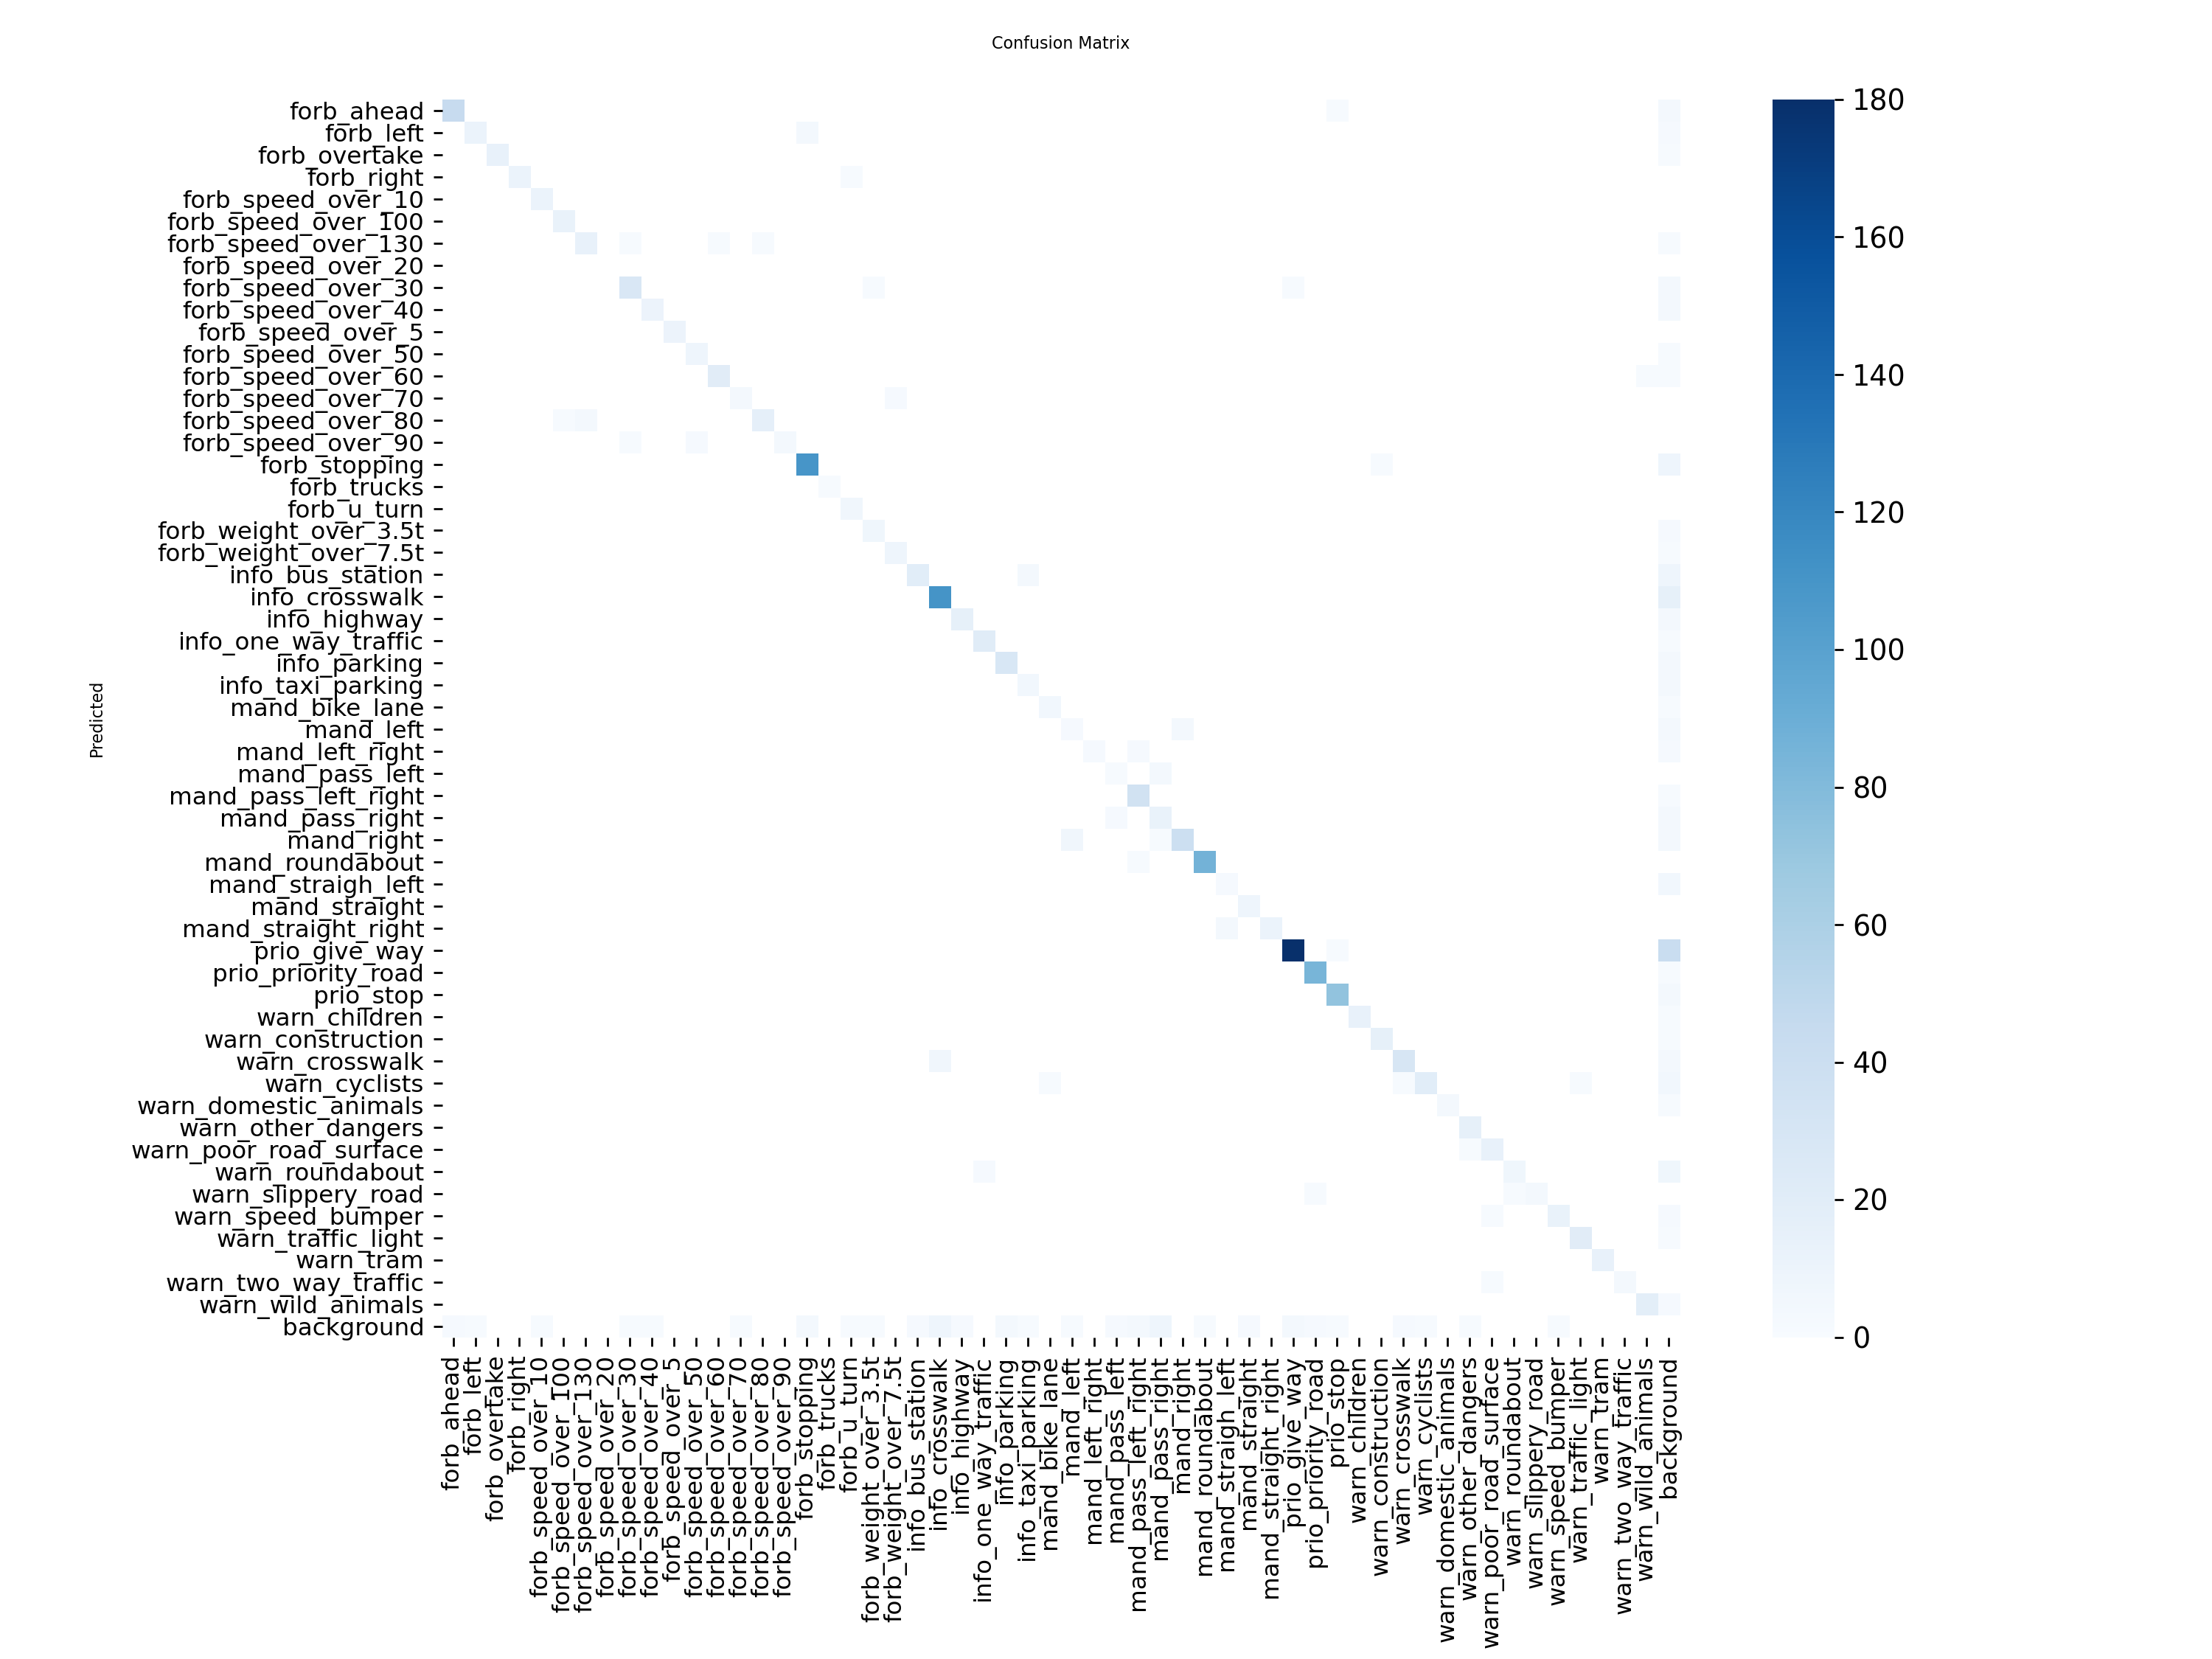

In [69]:
plot_confusion_matrix("baseline_55class_val")

# Analysis of Metrics and Graphs (Baseline, 55 classes)

## Training Dynamics (mAP50-95)
- Rapid growth during the first 10–20 epochs (≈0.23 → 0.7)
- Slower improvement after ~40 epochs
- Plateau after ~60 epochs
- Best result: **0.7964 (epoch 96)**

**Conclusion:**
- The model converges properly  
- Performance is close to the limit of the current setup  
- Further training gives only marginal improvements  

---

## Confusion Matrix

### Overall Pattern
- Strong diagonal indicates good class separation  
- Errors are structured rather than random  

---

### Main Issues

#### 1. Confusion within class groups
- `forb_speed_over_*` — difficult to distinguish (difference only in numbers)
- `mand_*` — confusion between directions (left/right/straight)
- `warn_*`, `info_*` — visually similar signs

**Conclusion:**  
The model learns **category-level features**, but struggles with **fine-grained distinctions**

---

#### 2. Vertical and horizontal patterns
- Some classes are predicted more frequently than others

**Possible causes:**
- class imbalance  
- dominant classes in the dataset  

---

#### 3. Background errors
- False positives and false negatives involving background
- Some objects are classified as background and vice versa

**Possible causes:**
- imbalance between object and background samples  
- small or low-quality objects  

---

## Train vs Validation
- Similar confusion matrices
- Same error patterns

**Conclusion:**
- No strong overfitting  
- Main limitations come from data and class design, not training  

---

## Overall Diagnosis
The model captures **high-level class groups well**,  
but struggles with **fine-grained differences within those groups**

---

## Summary

### Strengths
- Stable convergence
- mAP around 0.8 (solid baseline)
- No significant overfitting
- Good generalization

### Weaknesses
- Confusion between similar classes
- Dataset imbalance
- Limited sensitivity to small details
- Overly fine-grained class definitions

